# Evolução da OBMEP (2005–2025)

A Olimpíada Brasileira de Matemática das Escolas Públicas (OBMEP) é a maior competição científica do país, realizada pelo IMPA desde 2005. Este notebook analisa duas perguntas:

1. Como evoluiu a participação dos alunos ao longo dos anos?
2. A chance de um aluno ser premiado aumentou ou diminuiu?

**Dados usados:**
- `obmep.csv`: escolas, alunos e cobertura de municípios de 2005 a 2025, coletados manualmente na página oficial *OBMEP em Números*.
- `medalhas_obmep.csv`: medalhas e menções honrosas de 2005 a 2014, da tabela histórica de edições da OBMEP (Olimpédia).

## 0. Carregando os dados

Este notebook foi feito no Google Colab. Ao rodar a célula abaixo, selecione os dois arquivos CSV (`obmep.csv` e `medalhas_obmep.csv`) para enviá-los ao ambiente.

In [1]:
   from google.colab import files
   enviados = files.upload()

Saving medalhas_obmep.csv to medalhas_obmep (1).csv
Saving obmep.csv to obmep (1).csv


## 1. Medalhas: leitura e validação

A tabela de medalhas traz, para cada ano, o número de medalhas de ouro, prata e bronze, de menções honrosas e um total geral.

Antes de analisar, criei uma coluna só com as medalhas (ouro + prata + bronze) e conferi se o total da fonte bate com a soma das categorias. Em 2014 ele não bate: o total é 2.880 menor que a soma. Como não foi possível confirmar o valor correto na fonte oficial, o problema foi registrado na coluna `observacao`, e as análises seguintes usam a coluna `medalhas`, que é consistente em todos os anos.

In [2]:
import pandas as pd

medalhas = pd.read_csv("medalhas_obmep.csv")
medalhas.head()

,ano,ouro,prata,bronze,mencao_honrosa,total
0,2005,300,405,405,29999,31109
1,2006,300,405,405,33633,34743
2,2007,301,600,2101,30001,33003
3,2008,301,901,1803,30012,33017
4,2009,300,900,1800,30011,33011


In [3]:
medalhas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ano             10 non-null     int64
 1   ouro            10 non-null     int64
 2   prata           10 non-null     int64
 3   bronze          10 non-null     int64
 4   mencao_honrosa  10 non-null     int64
 5   total           10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [4]:
print(medalhas.shape)

(10, 6)


In [5]:
medalhas["medalhas"] = medalhas["ouro"] + medalhas["prata"] + medalhas["bronze"]
medalhas.head()

,ano,ouro,prata,bronze,mencao_honrosa,total,medalhas
0,2005,300,405,405,29999,31109,1110
1,2006,300,405,405,33633,34743,1110
2,2007,301,600,2101,30001,33003,3002
3,2008,301,901,1803,30012,33017,3005
4,2009,300,900,1800,30011,33011,3000


In [6]:
medalhas["confere"] = medalhas["medalhas"] + medalhas["mencao_honrosa"] == medalhas["total"]
medalhas[["ano", "medalhas", "mencao_honrosa", "total", "confere"]]

,ano,medalhas,mencao_honrosa,total,confere
0,2005,1110,29999,31109,True
1,2006,1110,33633,34743,True
2,2007,3002,30001,33003,True
3,2008,3005,30012,33017,True
4,2009,3000,30011,33011,True
5,2010,3208,30048,33256,True
6,2011,3200,30002,33202,True
7,2012,4504,40930,45434,True
8,2013,5999,38836,44835,True
9,2014,6501,42043,45664,False


In [7]:
medalhas["diferenca"] = medalhas["total"] - (medalhas["medalhas"] + medalhas["mencao_honrosa"])
medalhas[medalhas["confere"] == False]

,ano,ouro,prata,bronze,mencao_honrosa,total,medalhas,confere,diferenca
9,2014,501,1500,4500,42043,45664,6501,False,-2880


In [8]:
medalhas["observacao"] = ""
medalhas.loc[medalhas["ano"] == 2014, "observacao"] = "total nao bate com a soma (diferenca de 2880); fonte nao confirmada"
medalhas[["ano", "total", "confere", "observacao"]]

,ano,total,confere,observacao
0,2005,31109,True,
1,2006,34743,True,
2,2007,33003,True,
3,2008,33017,True,
4,2009,33011,True,
5,2010,33256,True,
6,2011,33202,True,
7,2012,45434,True,
8,2013,44835,True,
9,2014,45664,False,total nao bate com a soma (diferenca de 2880);...


## 2. Participantes: leitura e limpeza

Os dados de participação foram copiados da página oficial no formato brasileiro: ponto como separador de milhar (`10.520.831`) e porcentagem com vírgula (`93,5%`). Como o CSV usa vírgula para separar colunas, a porcentagem acabou dividida em duas partes.

Em vez de redigitar os dados, a limpeza foi feita no pandas: o parâmetro `thousands="."` converte os números, e as duas partes da porcentagem são juntadas de volta em uma coluna decimal (`municipios_pct`).

In [9]:
participantes = pd.read_csv(
    "obmep.csv",
    skiprows=1,
    header=None,
    names=["ano", "escolas", "alunos", "pct_inteiro", "pct_decimal"],
    thousands="."
)
participantes.head()

,ano,escolas,alunos,pct_inteiro,pct_decimal
0,2005,31031,10520831,93,5%
1,2006,32655,14181705,94,5%
2,2007,38450,17341732,98,1%
3,2008,40397,18326029,98,7%
4,2009,43854,19198710,99,1%


In [10]:
participantes["pct_decimal"] = participantes["pct_decimal"].str.replace("%", "")
participantes["municipios_pct"] = (participantes["pct_inteiro"].astype(str) + "." + participantes["pct_decimal"]).astype(float)
participantes.head()

,ano,escolas,alunos,pct_inteiro,pct_decimal,municipios_pct
0,2005,31031,10520831,93,5,93.5
1,2006,32655,14181705,94,5,94.5
2,2007,38450,17341732,98,1,98.1
3,2008,40397,18326029,98,7,98.7
4,2009,43854,19198710,99,1,99.1


In [11]:
participantes = participantes.drop(columns=["pct_inteiro", "pct_decimal"])
participantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ano             20 non-null     int64  
 1   escolas         20 non-null     int64  
 2   alunos          20 non-null     int64  
 3   municipios_pct  20 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 772.0 bytes


## 3. Evolução do número de alunos

Aqui calculo a variação percentual de alunos de um ano para o outro e mostro a série completa em um gráfico.

Dois cuidados: não houve edição em 2020 por causa da pandemia, então o gráfico interrompe a linha nesse ano em vez de ligar 2019 a 2021. Pelo mesmo motivo, a variação calculada para 2021 compara com 2019 e cobre dois anos, não um.

In [12]:
participantes["crescimento_alunos_pct"] = (participantes["alunos"].pct_change() * 100).round(1)
participantes[["ano", "alunos", "crescimento_alunos_pct"]]

,ano,alunos,crescimento_alunos_pct
0,2005,10520831,NaN
1,2006,14181705,34.8
2,2007,17341732,22.3
3,2008,18326029,5.7
4,2009,19198710,4.8
5,2010,19665928,2.4
6,2011,18720068,-4.8
7,2012,19166371,2.4
8,2013,18762859,-2.1
9,2014,18192526,-3.0


In [13]:
import matplotlib.pyplot as plt

serie = participantes.set_index("ano")["alunos"].reindex(range(2005, 2026))


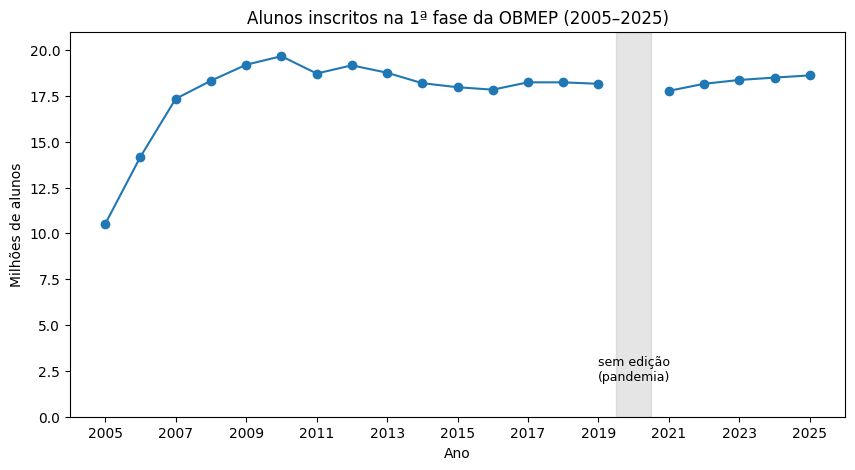

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(serie.index, serie / 1_000_000, marker="o")

plt.xticks(range(2005, 2026, 2))
plt.ylim(0, 21)

plt.axvspan(2019.5, 2020.5, color="gray", alpha=0.2)
plt.text(2020, 2, "sem edição\n(pandemia)", ha="center", fontsize=9)

plt.title("Alunos inscritos na 1ª fase da OBMEP (2005–2025)")
plt.ylabel("Milhões de alunos")
plt.xlabel("Ano")
plt.savefig("alunos_obmep.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Chance de premiação

Para saber se ficou mais fácil ou mais difícil ser premiado, juntei as duas tabelas pelo ano (2005 a 2014, período em que há dados de medalhas) e calculei quantos alunos são premiados a cada 100 mil participantes, separando medalhas de menções honrosas.

Essa separação é importante: as menções honrosas são cerca de 97% dos prêmios. Se as duas categorias forem somadas, o resultado reflete quase só as menções e esconde o que aconteceu com as medalhas.

No gráfico, cada linha tem seu próprio eixo Y, porque as escalas são muito diferentes. Por isso, o gráfico deve ser lido comparando cada linha com ela mesma ao longo do tempo, não uma linha com a outra.

In [15]:
juntos = participantes.merge(medalhas, on="ano", how="inner")
juntos[["ano", "alunos", "medalhas", "mencao_honrosa"]]

,ano,alunos,medalhas,mencao_honrosa
0,2005,10520831,1110,29999
1,2006,14181705,1110,33633
2,2007,17341732,3002,30001
3,2008,18326029,3005,30012
4,2009,19198710,3000,30011
5,2010,19665928,3208,30048
6,2011,18720068,3200,30002
7,2012,19166371,4504,40930
8,2013,18762859,5999,38836
9,2014,18192526,6501,42043


In [16]:
juntos["medalhas_por_100mil"] = (juntos["medalhas"] / juntos["alunos"] * 100_000).round(1)
juntos["mencoes_por_100mil"] = (juntos["mencao_honrosa"] / juntos["alunos"] * 100_000).round(1)
juntos[["ano", "medalhas_por_100mil", "mencoes_por_100mil"]]

,ano,medalhas_por_100mil,mencoes_por_100mil
0,2005,10.6,285.1
1,2006,7.8,237.2
2,2007,17.3,173.0
3,2008,16.4,163.8
4,2009,15.6,156.3
5,2010,16.3,152.8
6,2011,17.1,160.3
7,2012,23.5,213.6
8,2013,32.0,207.0
9,2014,35.7,231.1


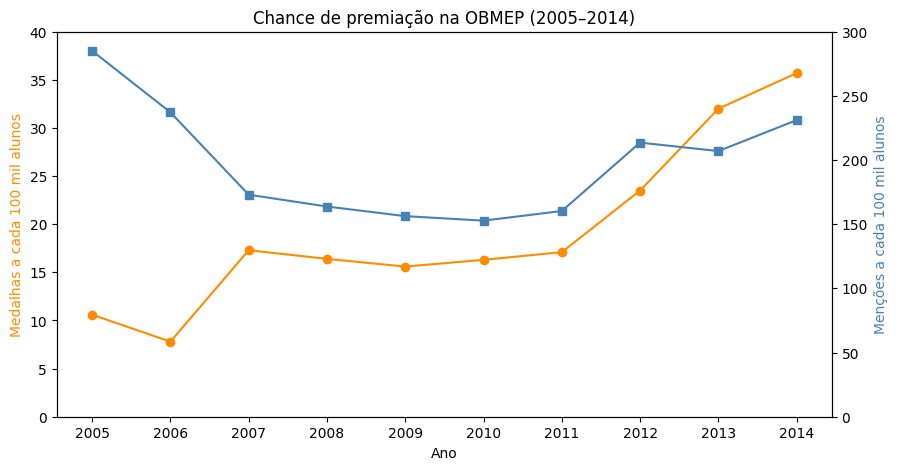

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(juntos["ano"], juntos["medalhas_por_100mil"], marker="o", color="darkorange", label="Medalhas")
ax1.set_ylabel("Medalhas a cada 100 mil alunos", color="darkorange")
ax1.set_ylim(0, 40)

ax2 = ax1.twinx()
ax2.plot(juntos["ano"], juntos["mencoes_por_100mil"], marker="s", color="steelblue", label="Menções honrosas")
ax2.set_ylabel("Menções a cada 100 mil alunos", color="steelblue")
ax2.set_ylim(0, 300)

ax1.set_xticks(range(2005, 2015))
ax1.set_xlabel("Ano")
plt.title("Chance de premiação na OBMEP (2005–2014)")
plt.savefig("premiacao_obmep.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusões

**1. A OBMEP cresceu rápido e depois estabilizou.**
O número de alunos inscritos na 1ª fase passou de 10,5 milhões em 2005 para 18,6 milhões em 2025 (+77%). Quase todo esse crescimento aconteceu nos primeiros anos: o pico foi em 2010, com 19,7 milhões de alunos. Depois disso, a participação se manteve estável, em torno de 18 milhões, e em 2025 ainda estava cerca de 5% abaixo do pico. A cobertura de municípios foi de 93,5% em 2005 para 99,93% em 2025, ou seja, a olimpíada já chega a praticamente todas as cidades do país.

**2. Ganhar medalha ficou mais fácil; ganhar menção honrosa, mais difícil.**
Entre 2005 e 2014, a chance de ganhar medalha (ouro, prata ou bronze) passou de 10,6 para 35,7 a cada 100 mil alunos — mais que o triplo, puxada pelo aumento das vagas de bronze em 2007 e a partir de 2012. Já a chance de menção honrosa caiu de 285 para 231 a cada 100 mil alunos, chegando ao ponto mais baixo em 2010 (153), o ano com mais participantes.

**3. Esta análise corrige uma versão anterior do projeto.**
Numa primeira versão, concluí que ganhar medalha tinha ficado mais difícil. O erro veio de usar uma coluna de "total" que somava medalhas e menções honrosas — como as menções eram cerca de 97% desse total, a análise media, na prática, a chance de menção. Separando as duas categorias e usando a série completa de participantes (antes eu tinha só 6 anos), a conclusão se inverteu.

**4. Problemas encontrados nos dados e como foram tratados.**
- **2020 não existe na série:** não houve edição por causa da pandemia. Nos gráficos, a linha é interrompida nesse ano, em vez de ligar 2019 a 2021. A variação calculada para 2021 compara com 2019, ou seja, cobre dois anos.
- **Inconsistência em 2014:** na fonte das medalhas, o total informado é 2.880 menor que a soma de medalhas + menções. Como não foi possível confirmar o número certo na fonte oficial, o problema foi registrado no notebook, e as análises usam a soma de ouro + prata + bronze, que é consistente em todos os anos. O número de menções honrosas de 2014 pode estar afetado.
- **Formato dos dados coletados:** os números vieram com ponto de milhar e porcentagens com vírgula. A limpeza foi feita no próprio pandas, sem redigitar os dados.

**Fontes:** participantes, escolas e municípios — página oficial *OBMEP em Números* (obmep.org.br). Medalhas 2005–2014 — tabela histórica de edições da OBMEP (Olimpédia).